# Benchmarking Surrogate Models

In [1]:
# ============================================================
# Imports & Global Setup
# ============================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dice_ml
import random
import json
import datetime

from pathlib import Path
from dice_ml import Dice
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor,
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import BayesianRidge, ElasticNet, HuberRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

SEED = 42

## 1. Load Surrogate Dataset

In [2]:
# -----------------------------
# 1) Load
# -----------------------------
CSV_PATH = "surrogate_ready_dataset/patchcore_surrogate_dataset_xgb.csv"
df = pd.read_csv(CSV_PATH)

print("Loaded:", CSV_PATH)
print("Shape:", df.shape)
display(df.head())

Loaded: surrogate_ready_dataset/patchcore_surrogate_dataset_xgb.csv
Shape: (2999, 14)


,value,params_backbone,params_batch_size,params_center_crop_key,params_coreset_sampling_ratio,params_image_size_key,params_layers_key,params_max_patches_per_image,params_num_neighbors,params_pre_trained,params_reduction,params_soft_corruption_level,params_soft_review_budget,params_soft_train_fraction
0,0.695060,wide_resnet50_2,8,0.875,0.055,256,l3,1024,25,True,max,none,0.330,0.50
1,0.090909,resnet34,8,0.875,0.099,320,l2,128,26,True,mean,none,0.110,0.61
2,0.578411,resnet34,8,0.875,0.003,256,l2_l3,512,25,True,max,strong,0.220,0.66
3,0.095665,wide_resnet50_2,8,none,0.093,320,l2,512,25,True,max,strong,0.425,0.34
4,0.000000,resnet50,8,none,0.045,256,l2,128,16,False,mean,mild,0.060,0.50


## 2. Train/Test Split (Stratified for Regression)

In [3]:
# -----------------------------
# 2) Split 80/20 (stratified for regression)
# -----------------------------
TARGET = "value"
X = df.drop(columns=[TARGET])
y = df[TARGET]

y_series = y.reset_index(drop=True)

is_zero = (y_series == 0.0)
strat = pd.Series(index=y_series.index, dtype="object")
strat[is_zero] = "zero"

n_bins = 10
nonzero = y_series[~is_zero]
qbins = pd.qcut(nonzero, q=n_bins, duplicates="drop")
strat.loc[nonzero.index] = qbins.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    shuffle=True,
    stratify=strat
)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape,  y_test.shape)
print("Zero rate train:", float((y_train == 0.0).mean()))
print("Zero rate test: ", float((y_test == 0.0).mean()))


Train: (2399, 13) (2399,)
Test:  (600, 13) (600,)
Zero rate train: 0.007503126302626094
Zero rate test:  0.006666666666666667


## 3. Feature Schema & Preprocessing

In [4]:
# -----------------------------
# 3) Feature schema
# -----------------------------
categorical_features = [
    "params_backbone",
    "params_batch_size",
    "params_center_crop_key",
    "params_image_size_key",
    "params_layers_key",
    "params_max_patches_per_image",
    "params_pre_trained",
    "params_reduction",
    "params_soft_corruption_level",
]

numeric_features = [
    "params_coreset_sampling_ratio",
    "params_num_neighbors",
    "params_soft_review_budget",
    "params_soft_train_fraction",
]

assert set(categorical_features + numeric_features) == set(X_train.columns), "Feature lists mismatch"

print("Categorical:", len(categorical_features), categorical_features)
print("Numeric:", len(numeric_features), numeric_features)


Categorical: 9 ['params_backbone', 'params_batch_size', 'params_center_crop_key', 'params_image_size_key', 'params_layers_key', 'params_max_patches_per_image', 'params_pre_trained', 'params_reduction', 'params_soft_corruption_level']
Numeric: 4 ['params_coreset_sampling_ratio', 'params_num_neighbors', 'params_soft_review_budget', 'params_soft_train_fraction']


In [5]:
# -----------------------------
# 4) Preprocessing (sklearn models)
# -----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ],
    remainder="drop",
)


## 4. Baseline Benchmark (sklearn models)

In [6]:
# -----------------------------
# 5) Benchmark utilities
# -----------------------------
def eval_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return rmse, mae, r2

def benchmark(models, X_train, y_train, X_test, y_test, preprocess):
    rows = []
    fitted = {}

    for name, est in models.items():
        pipe = Pipeline([("prep", preprocess), ("model", clone(est))])

        try:
            t0 = time.time()
            pipe.fit(X_train, y_train)
            fit_sec = time.time() - t0

            y_pred = pipe.predict(X_test)
            rmse, mae, r2 = eval_regression(y_test, y_pred)

            rows.append({
                "model": name,
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "fit_sec": fit_sec,
                "status": "ok",
            })
            fitted[name] = pipe

        except Exception as e:
            rows.append({
                "model": name,
                "rmse": np.nan,
                "mae": np.nan,
                "r2": np.nan,
                "fit_sec": np.nan,
                "status": f"fail: {type(e).__name__}",
            })
            print(f"[WARN] {name} failed -> {type(e).__name__}: {e}")

    res = pd.DataFrame(rows).sort_values(["rmse", "mae"], ascending=[True, True]).reset_index(drop=True)
    return res, fitted


In [7]:
# -----------------------------
# 6) Model zoo (sklearn benchmark)
# -----------------------------
models = {
    "HistGBDT": HistGradientBoostingRegressor(random_state=SEED),
    "RandomForest": RandomForestRegressor(n_estimators=400, random_state=SEED, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=800, random_state=SEED, n_jobs=-1),
    "GBDT": GradientBoostingRegressor(random_state=SEED),

    "XGBoost": XGBRegressor(
        n_estimators=800,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    ),

    "AdaBoost": AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4, random_state=SEED),
        n_estimators=400,
        learning_rate=0.05,
        random_state=SEED,
    ),
    "DecisionTree": DecisionTreeRegressor(random_state=SEED),
    "KNN": KNeighborsRegressor(n_neighbors=25, weights="distance"),
    "SVR(RBF)": SVR(C=10.0, epsilon=0.02, gamma="scale"),

    "BayesianRidge": BayesianRidge(),
    "ElasticNet": ElasticNet(alpha=1e-3, l1_ratio=0.2, random_state=SEED),
    "Huber": HuberRegressor(),
}

print("Models:", list(models.keys()))


Models: ['HistGBDT', 'RandomForest', 'ExtraTrees', 'GBDT', 'XGBoost', 'AdaBoost', 'DecisionTree', 'KNN', 'SVR(RBF)', 'BayesianRidge', 'ElasticNet', 'Huber']


In [8]:
# -----------------------------
# 7) Run sklearn benchmark
# -----------------------------
results, fitted_pipes = benchmark(models, X_train, y_train, X_test, y_test, preprocess)

display(results)
best_sklearn = results.loc[results["status"] == "ok"].iloc[0]["model"]
print("Best (sklearn benchmark):", best_sklearn)


/home/jovyan/.conda/envs/pdt_hpo_xai_patchcore/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,model,rmse,mae,r2,fit_sec,status
0,HistGBDT,0.085339,0.043047,0.936766,0.253480,ok
1,RandomForest,0.086097,0.043862,0.935636,0.377162,ok
2,ExtraTrees,0.086506,0.040160,0.935023,0.552880,ok
3,GBDT,0.086652,0.050862,0.934804,0.233943,ok
4,XGBoost,0.090017,0.043371,0.929642,0.394981,ok
5,AdaBoost,0.108058,0.078125,0.898614,0.935021,ok
6,SVR(RBF),0.118906,0.076873,0.877237,0.234119,ok
7,DecisionTree,0.121904,0.056034,0.870968,0.012600,ok
8,KNN,0.134294,0.074241,0.843406,0.004928,ok
9,BayesianRidge,0.135682,0.101946,0.840153,0.010102,ok


Best (sklearn benchmark): HistGBDT


In [9]:
# -----------------------------
# 8) CatBoost setup (native categorical handling)
# -----------------------------

# Copy to avoid mutating X_train / X_test used by sklearn pipelines
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

# Ensure categoricals are strings (CatBoost categorical processing expects this)
for c in categorical_features:
    X_train_cb[c] = X_train_cb[c].astype(str)
    X_test_cb[c] = X_test_cb[c].astype(str)

# CatBoost needs categorical feature indices
cat_features_idx = [X_train_cb.columns.get_loc(c) for c in categorical_features]

print("CatBoost categorical feature indices:", cat_features_idx)
print("CatBoost categorical features:", categorical_features)


CatBoost categorical feature indices: [0, 1, 2, 4, 5, 6, 8, 9, 10]
CatBoost categorical features: ['params_backbone', 'params_batch_size', 'params_center_crop_key', 'params_image_size_key', 'params_layers_key', 'params_max_patches_per_image', 'params_pre_trained', 'params_reduction', 'params_soft_corruption_level']


In [10]:
# -----------------------------
# 9) Train CatBoost (early stopping)
# -----------------------------
cb = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=5000,          # early stopping will select the best iteration
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3.0,
    random_seed=SEED,
    verbose=200,
)

t0 = time.time()
cb.fit(
    X_train_cb, y_train,
    cat_features=cat_features_idx,
    eval_set=(X_test_cb, y_test),
    use_best_model=True,
    early_stopping_rounds=200,
)
cb_fit_sec = time.time() - t0

print("CatBoost fit_sec:", cb_fit_sec)


0:	learn: 0.3251202	test: 0.3261753	best: 0.3261753 (0)	total: 53.1ms	remaining: 4m 25s
200:	learn: 0.0517805	test: 0.0859080	best: 0.0859080 (200)	total: 1.22s	remaining: 29.1s
400:	learn: 0.0344028	test: 0.0861130	best: 0.0857559 (233)	total: 2.39s	remaining: 27.4s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.08575594179
bestIteration = 233

Shrink model to first 234 iterations.
CatBoost fit_sec: 2.6495954990386963


In [11]:
# -----------------------------
# 10) Evaluate CatBoost + merge into benchmark table
# -----------------------------
y_pred_cb = cb.predict(X_test_cb)
rmse_cb, mae_cb, r2_cb = eval_regression(y_test, y_pred_cb)

print(f"CatBoost(native) -> RMSE: {rmse_cb:.6f} | MAE: {mae_cb:.6f} | R²: {r2_cb:.6f}")

cb_row = pd.DataFrame([{
    "model": "CatBoost(native)",
    "rmse": rmse_cb,
    "mae": mae_cb,
    "r2": r2_cb,
    "fit_sec": cb_fit_sec,
    "status": "ok",
}])

results_all = (
    pd.concat([results, cb_row], ignore_index=True)
      .sort_values(["rmse", "mae"], ascending=[True, True])
      .reset_index(drop=True)
)

display(results_all)

best_overall = results_all.loc[results_all["status"] == "ok"].iloc[0]["model"]
print("Best (overall incl. CatBoost):", best_overall)


CatBoost(native) -> RMSE: 0.085756 | MAE: 0.045853 | R²: 0.936146


,model,rmse,mae,r2,fit_sec,status
0,HistGBDT,0.085339,0.043047,0.936766,0.253480,ok
1,CatBoost(native),0.085756,0.045853,0.936146,2.649595,ok
2,RandomForest,0.086097,0.043862,0.935636,0.377162,ok
3,ExtraTrees,0.086506,0.040160,0.935023,0.552880,ok
4,GBDT,0.086652,0.050862,0.934804,0.233943,ok
5,XGBoost,0.090017,0.043371,0.929642,0.394981,ok
6,AdaBoost,0.108058,0.078125,0.898614,0.935021,ok
7,SVR(RBF),0.118906,0.076873,0.877237,0.234119,ok
8,DecisionTree,0.121904,0.056034,0.870968,0.012600,ok
9,KNN,0.134294,0.074241,0.843406,0.004928,ok


Best (overall incl. CatBoost): HistGBDT


## 5. Final Surrogate: CatBoost (Native Categoricals)

In [12]:
# -----------------------------
# 11) Select final surrogate (fixed choice)
# -----------------------------
FINAL_MODEL = "CatBoost(native)"
print("Selected surrogate:", FINAL_MODEL)


Selected surrogate: CatBoost(native)


In [13]:
# -----------------------------
# 12) CatBoost predictions (test set)
# -----------------------------
y_true = y_test.values if hasattr(y_test, "values") else y_test
y_pred = np.asarray(cb.predict(X_test_cb))

residuals = y_true - y_pred
abs_err = np.abs(residuals)

print("CatBoost(native) evaluation on test")
print("y_true: min/max =", float(np.min(y_true)), float(np.max(y_true)))
print("y_pred: min/max =", float(np.min(y_pred)), float(np.max(y_pred)))


CatBoost(native) evaluation on test
y_true: min/max = 0.0 0.9066666666666666
y_pred: min/max = -0.004365825528847567 0.8970722949076886


## 6. Surrogate Diagnostics (CatBoost)

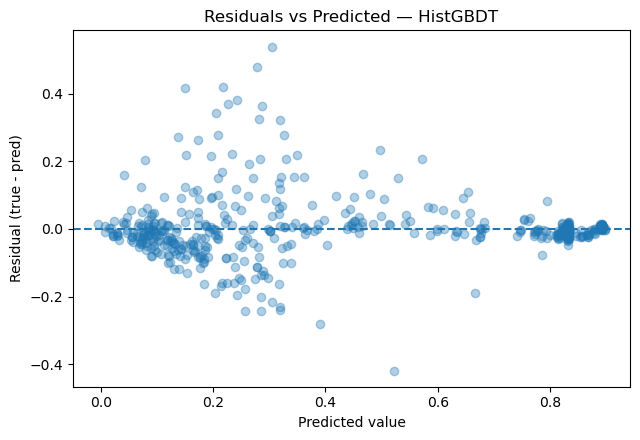

In [14]:
# -----------------------------
# 13) Residuals vs Predicted
# -----------------------------
plt.figure(figsize=(6.5, 4.5))
plt.scatter(y_pred, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted value")
plt.ylabel("Residual (true - pred)")
plt.title(f"Residuals vs Predicted — {best_overall}")
plt.tight_layout()
plt.show()


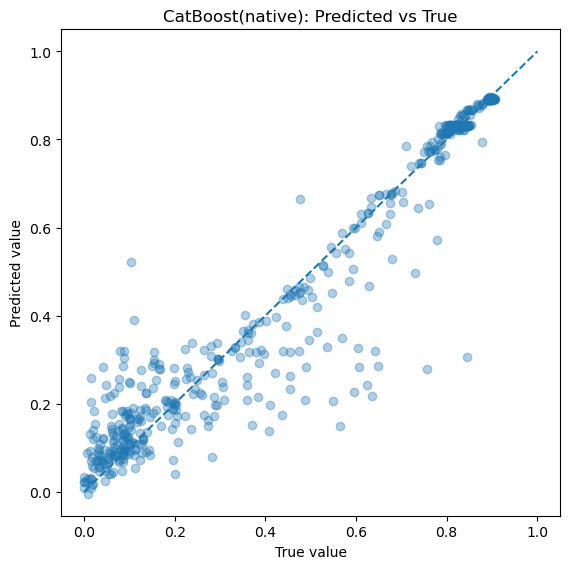

In [15]:
# -----------------------------
# 14) Predicted vs True (CatBoost)
# -----------------------------
plt.figure(figsize=(5.8, 5.8))
plt.scatter(y_true, y_pred, alpha=0.35)
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.title("CatBoost(native): Predicted vs True")
plt.tight_layout()
plt.show()


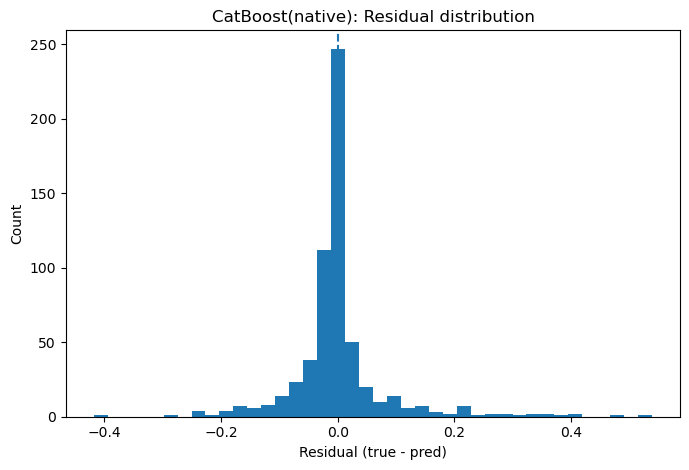

In [16]:
# -----------------------------
# 16) Residual histogram (CatBoost)
# -----------------------------
plt.figure(figsize=(7.0, 4.8))
plt.hist(residuals, bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual (true - pred)")
plt.ylabel("Count")
plt.title("CatBoost(native): Residual distribution")
plt.tight_layout()
plt.show()


,bin,mean,median,count
0,"(-0.001, 0.0604]",0.058442,0.036281,60
1,"(0.0604, 0.0992]",0.060490,0.038917,60
2,"(0.0992, 0.185]",0.063924,0.047327,60
3,"(0.185, 0.357]",0.047514,0.040270,60
4,"(0.357, 0.572]",0.095573,0.060509,60
5,"(0.572, 0.785]",0.083089,0.024320,60
6,"(0.785, 0.823]",0.017472,0.016725,60
7,"(0.823, 0.843]",0.007328,0.006001,60
8,"(0.843, 0.895]",0.016489,0.002964,62
9,"(0.895, 0.907]",0.007919,0.007482,58


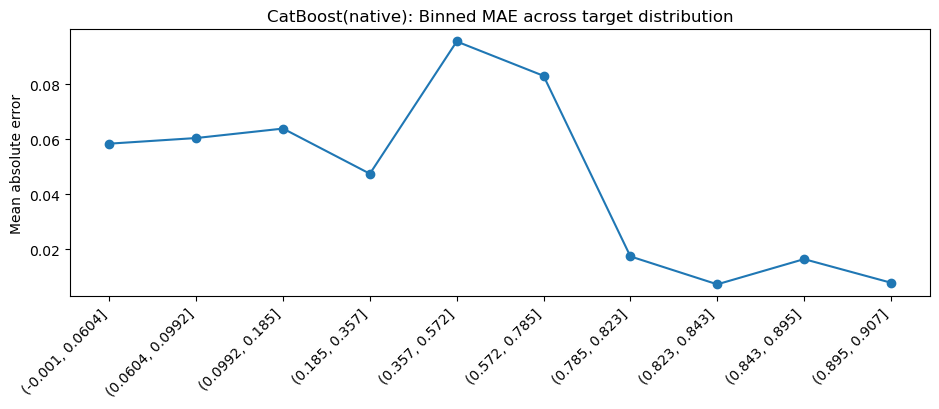

In [17]:
# -----------------------------
# 17) Error by target region (CatBoost)
# -----------------------------
bins = pd.qcut(pd.Series(y_true), q=10, duplicates="drop")
err_by_bin = (
    pd.DataFrame({"bin": bins.astype(str), "abs_err": abs_err})
      .groupby("bin")["abs_err"]
      .agg(mean="mean", median="median", count="count")
      .reset_index()
)

display(err_by_bin)

plt.figure(figsize=(9.5, 4.2))
plt.plot(range(len(err_by_bin)), err_by_bin["mean"], marker="o")
plt.xticks(range(len(err_by_bin)), err_by_bin["bin"], rotation=45, ha="right")
plt.ylabel("Mean absolute error")
plt.title("CatBoost(native): Binned MAE across target distribution")
plt.tight_layout()
plt.show()


,bin,y_true_mean,y_pred_mean,n
0,"(-0.00537, 0.0884]",0.056977,0.057420,60
1,"(0.0884, 0.142]",0.088101,0.112432,60
2,"(0.142, 0.208]",0.175175,0.174497,60
3,"(0.208, 0.3]",0.261873,0.250942,60
4,"(0.3, 0.466]",0.392971,0.366712,60
5,"(0.466, 0.789]",0.663242,0.651172,60
6,"(0.789, 0.831]",0.816350,0.822488,60
7,"(0.831, 0.833]",0.827264,0.832181,60
8,"(0.833, 0.892]",0.874473,0.876612,61
9,"(0.892, 0.897]",0.897792,0.892499,59


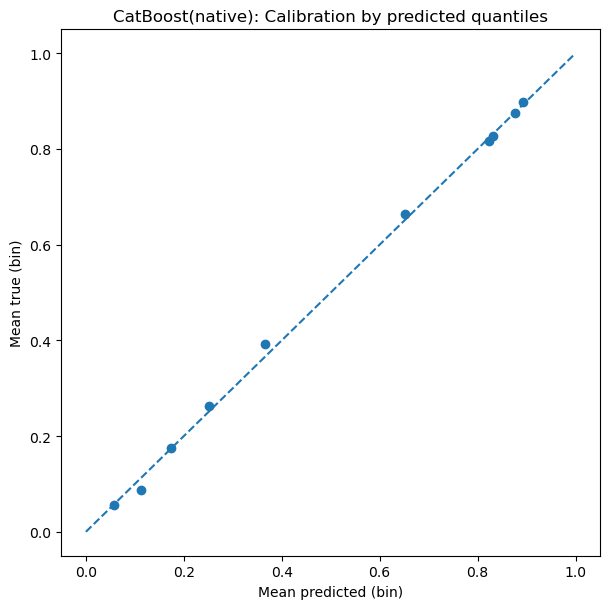

In [18]:
# -----------------------------
# 18) Calibration (bin means: true vs predicted)
# -----------------------------
cal_bins = pd.qcut(pd.Series(y_pred), q=10, duplicates="drop")
cal = (
    pd.DataFrame({"bin": cal_bins.astype(str), "y_true": y_true, "y_pred": y_pred})
      .groupby("bin")
      .agg(y_true_mean=("y_true", "mean"), y_pred_mean=("y_pred", "mean"), n=("y_true", "size"))
      .reset_index()
)

display(cal)

plt.figure(figsize=(6.2, 6.2))
plt.scatter(cal["y_pred_mean"], cal["y_true_mean"])
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("Mean predicted (bin)")
plt.ylabel("Mean true (bin)")
plt.title("CatBoost(native): Calibration by predicted quantiles")
plt.tight_layout()
plt.show()


## Export CFs + metadata

In [30]:
# 19) Save surrogate model (CatBoost)
OUT_DIR = Path("surrogate_pkl_cfs_metadata")
OUT_DIR.mkdir(parents=True, exist_ok=True)

model_path = OUT_DIR / f"surrogate_catboost.cbm"
cb.save_model(str(model_path))

print(" - model:   ", model_path)

 - model:    outputs_counterfactuals/surrogate_catboost_20260209_102903.cbm
